# Chapter 5

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, coint
import scipy.optimize
from scipy import stats
from sklearn.metrics import r2_score
from pprint import pprint

from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, classification_report, confusion_matrix, accuracy_score

from utils.sampling_bars import dollar_bar
from utils.multiprocess import mpPandasObj
from utils.labeling import get_daily_vol, symmetric_cusum_filter, get_vertical_bars, get_events, get_bins
from utils.frac_diff import frac_diff_ffd

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

data_path = '../data/processed/clean_IVE_tickbidask.parq'
df = pd.read_parquet(data_path)

dollar_bars = dollar_bar(df)

In [2]:
# sample the dollar bar to prevent running to long
print(f"Original number of rows: {len(dollar_bars)}")
dollar_bars = dollar_bars[int(len(dollar_bars) * 0.75): ]
print(f"Sampled number of rows: {len(dollar_bars)}")

Original number of rows: 1443691
Sampled number of rows: 360923


In [11]:
dollar_bars.head()

,price,bid,ask,vol,dollar_vol,trade_count,price_high,price_low,log_price,cum_log_price
date,,,,,,,,,,
2022-09-29 09:31:37,131.47000,131.45,131.47,1000.0,131470.0,8.0,131.47,131.47,4.878779,4.878779
2022-09-29 09:32:14,131.30000,131.28,131.32,200.0,26260.0,2.0,131.30,131.30,4.877485,9.756263
2022-09-29 09:32:45,131.16000,131.16,131.18,200.0,26232.0,2.0,131.16,131.16,4.876418,14.632681
2022-09-29 09:32:50,131.07125,131.01,131.08,800.0,104857.0,8.0,131.10,131.06,4.875741,19.508422
2022-09-29 09:32:51,131.07000,131.07,131.08,800.0,104856.0,6.0,131.07,131.07,4.875732,24.384154


## 5. Take the dollar bar series on E-mini S&P 500 futures.

### a. Form a new series as a cumulative sum of log-prices.

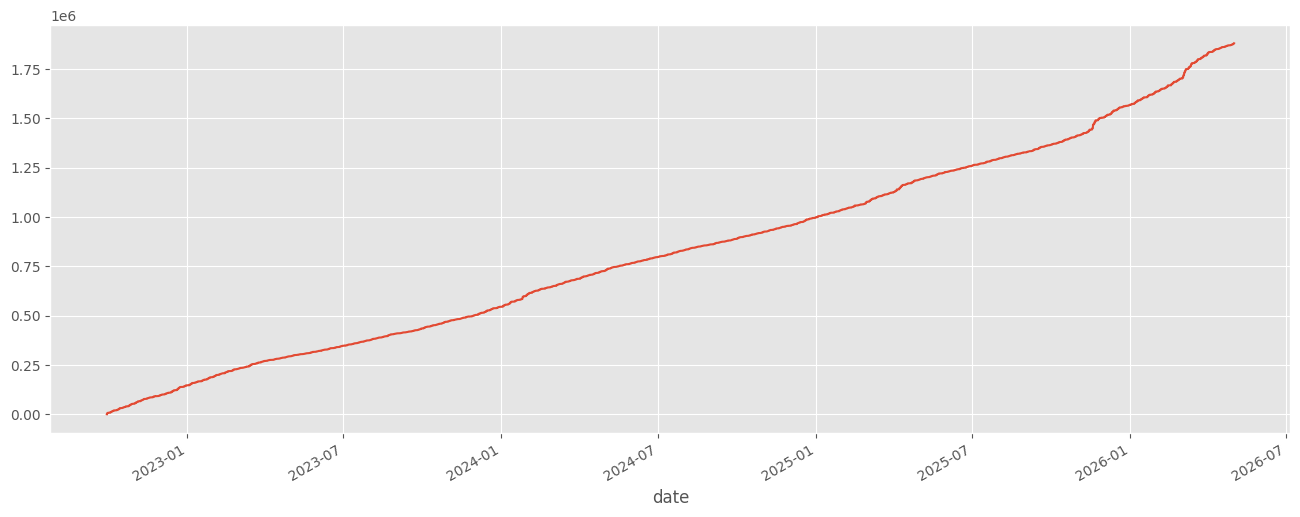

In [3]:
dollar_bars['log_price'] = np.log(dollar_bars['price'])
dollar_bars['cum_log_price'] = dollar_bars['log_price'].cumsum()

# plot the graph of the cumulative sum of log-prices
dollar_bars['cum_log_price'].plot()
plt.show()

### b. Apply FFD, with τ = 1E − 5. Determine for what minimum d ∈ [0, 2] the  new series is stationary.

Finished d: 0.0
Finished d: 0.22222222
Finished d: 0.44444444
Finished d: 0.66666667
Finished d: 0.88888889
Finished d: 1.11111111
Finished d: 1.33333333
Finished d: 1.55555556
Finished d: 1.77777778
Finished d: 2.0
Minimum d value to get p-value < 5%: 2.0


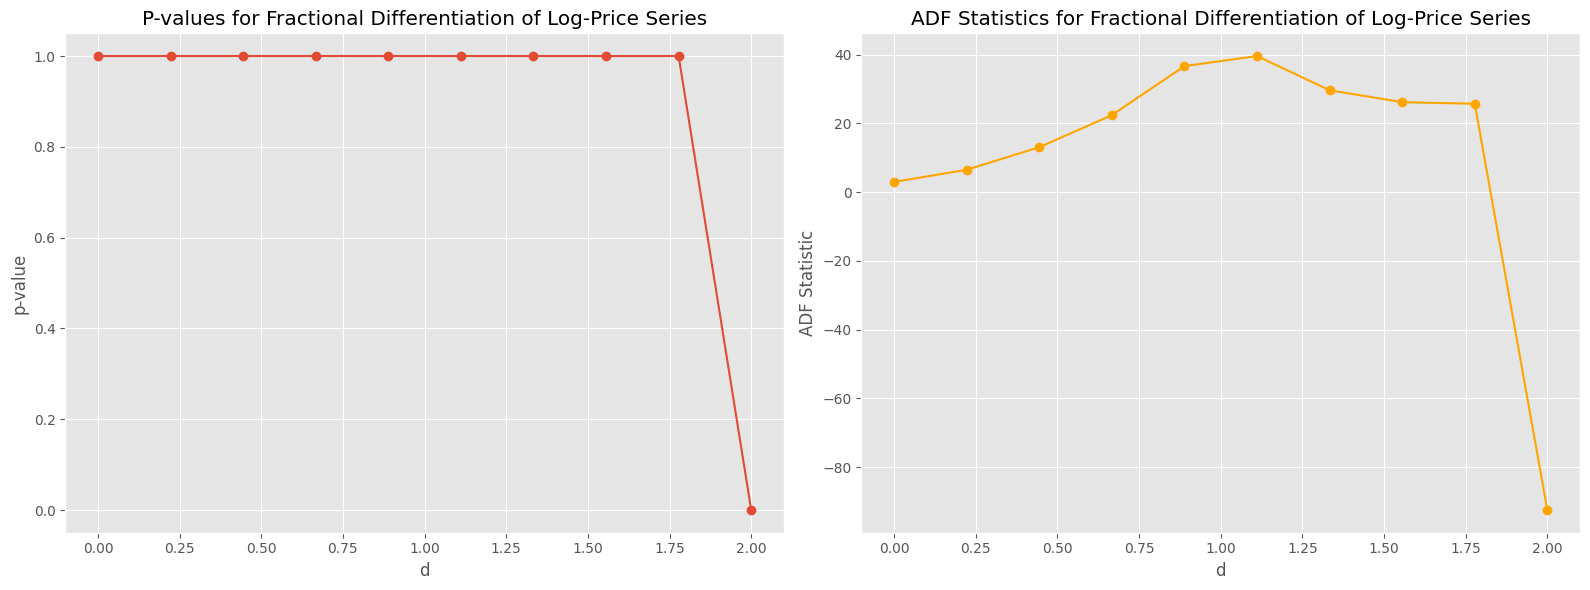

In [4]:
p_values = []
adf_stats = []

x_range_0_2 = np.linspace(0, 2, 10)
min_d = None

cum_log_price_df = dollar_bars[['cum_log_price']]
frac_diff_results = {}

for d in x_range_0_2:
    d_key = float(np.round(d, 8))
    frac_diff_ffd_log_price = frac_diff_ffd(cum_log_price_df, d_key, tau=1e-5)['cum_log_price']
    frac_diff_results[d_key] = frac_diff_ffd_log_price

    frac_diff_clean = frac_diff_ffd_log_price.dropna()
    if frac_diff_clean.empty:
        p_values.append(np.nan)
        adf_stats.append(np.nan)
        print(f"Skipped d={d_key}: no valid points after FFD")
        continue

    result_frac_diff = adfuller(frac_diff_clean.to_numpy(), autolag='AIC')
    p_values.append(result_frac_diff[1])
    adf_stats.append(result_frac_diff[0])

    if result_frac_diff[1] < 0.05 and min_d is None:
        min_d = d_key

    print(f"Finished d: {d_key}")

print(f"Minimum d value to get p-value < 5%: {min_d}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(x_range_0_2, p_values, marker='o')
axes[0].set_title("P-values for Fractional Differentiation of Log-Price Series")
axes[0].set_xlabel("d")
axes[0].set_ylabel("p-value")

axes[1].plot(x_range_0_2, adf_stats, marker='o', color='orange')
axes[1].set_title("ADF Statistics for Fractional Differentiation of Log-Price Series")
axes[1].set_xlabel("d")
axes[1].set_ylabel("ADF Statistic")

plt.tight_layout()
plt.show()

### c. Compute the correlation of the fracdiff series to the original  (untransformed) series.

In [5]:
# we use the min_d with p-value < 5% to get the correlation

if min_d is None:
    raise ValueError("No stationary d found in the searched range.")

min_d_key = float(np.round(min_d, 8))
frac_diff_ffd_log_price_best = frac_diff_results[min_d_key]

aligned = pd.concat(
    [
        dollar_bars['log_price'].rename('log_price'),
        frac_diff_ffd_log_price_best.rename('fracdiff')
    ],
    axis=1
).dropna()

# Keep aligned finite series for subsequent tests.
log_price_aligned = aligned['log_price']
frac_diff_ffd_log_price_best = aligned['fracdiff']

corr = np.corrcoef(log_price_aligned.to_numpy(), frac_diff_ffd_log_price_best.to_numpy())[0, 1]

print(f"Correlation of the fracdiff series to the original log prices: {corr}")

Correlation of the fracdiff series to the original log prices: -3.637373415696659e-05


### d. Apply an Engel-Granger cointegration test on the original and fracdiff  series. Are they cointegrated? Why?

In [6]:
score, pvalue, crit_value = coint(log_price_aligned, frac_diff_ffd_log_price_best)

print(f"Engel-Granger cointegration test score: {score}")
print(f"Engel-Granger cointegration test p-value: {pvalue}")
print(f"Engel-Granger cointegration test critical value: {crit_value}")

Engel-Granger cointegration test score: -1.9530771593126677
Engel-Granger cointegration test p-value: 0.5528661555446653
Engel-Granger cointegration test critical value: [-3.89647034 -3.33614693 -3.04446175]


They are not cointegrated.

### e. Apply a Jarque-Bera normality test on the fracdiff series.

In [7]:
res = stats.jarque_bera(frac_diff_ffd_log_price_best)

print(f"JB Statistic: {res.statistic}")
print(f"P-value: {res.pvalue}")

JB Statistic: 3087288037.999001
P-value: 0.0


## 6. Take the fracdiff series from exercise 5.

### a. Apply a CUSUM filter (Chapter 2), where h is twice the standard  deviation of the series.

In [8]:
daily_vol = get_daily_vol(frac_diff_ffd_log_price_best, span0=1000)
t_events = symmetric_cusum_filter(frac_diff_ffd_log_price_best, daily_vol * 2)
len(t_events), t_events[:5]

/Users/lucaswychan/advances-in-financial-ml-exercises/utils/labeling.py:23: RuntimeWarning: divide by zero encountered in divide
  close.iloc[current_pos].to_numpy() / close.iloc[prev_pos].to_numpy() - 1,
/Users/lucaswychan/advances-in-financial-ml-exercises/utils/labeling.py:23: RuntimeWarning: invalid value encountered in divide
  close.iloc[current_pos].to_numpy() / close.iloc[prev_pos].to_numpy() - 1,
/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/lucaswychan/advances-in-financial-ml-exercises/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


(11506,
 DatetimeIndex(['2022-09-30 09:40:31', '2022-09-30 09:41:00',
                '2022-09-30 10:46:00', '2022-09-30 12:58:47',
                '2022-09-30 13:00:54'],
               dtype='datetime64[us]', freq=None))

### b. Use the filtered timestamps to sample a features’ matrix. Use as one of  the features the fracdiff value.

In [12]:
def relative_strength_index(df, n):
    """ Calculate Relative Strength Index(RSI) for given data.
    https://github.com/Crypto-toolbox/pandas-technical-indicators/blob/master/technical_indicators.py

    :param df: pandas.DataFrame
    :param n: 
    :return: pandas.DataFrame
    """
    i = 0
    UpI = [0]
    DoI = [0]
    while i + 1 <= df.index[-1]:
        UpMove = df.loc[i + 1, 'price_high'] - df.loc[i, 'price_high']
        DoMove = df.loc[i, 'price_low'] - df.loc[i + 1, 'price_low']
        if UpMove > DoMove and UpMove > 0:
            UpD = UpMove
        else:
            UpD = 0
        UpI.append(UpD)
        if DoMove > UpMove and DoMove > 0:
            DoD = DoMove
        else:
            DoD = 0
        DoI.append(DoD)
        i = i + 1
    UpI = pd.Series(UpI)
    DoI = pd.Series(DoI)
    PosDI = pd.Series(UpI.ewm(span=n, min_periods=n).mean())
    NegDI = pd.Series(DoI.ewm(span=n, min_periods=n).mean())
    RSI = pd.Series(round(PosDI * 100. / (PosDI + NegDI)), name='RSI_' + str(n))
    return RSI

# Compute RSI
def get_rsi(data, window=14):
    df = data.copy(deep=True).reset_index()
    rsi = relative_strength_index(df, window)
    rsi_df = pd.Series(data=rsi.values, index=data.index)
    return rsi_df

In [ ]:
rsi_df = get_rsi(dollar_bars, window=100)

rsi_df.head()

date
2022-09-29 09:31:37   NaN
2022-09-29 09:32:14   NaN
2022-09-29 09:32:45   NaN
2022-09-29 09:32:50   NaN
2022-09-29 09:32:51   NaN
dtype: float64

In [14]:
rsi_df.tail()

date
2026-05-01 15:59:08    40.0
2026-05-01 15:59:23    39.0
2026-05-01 15:59:32    40.0
2026-05-01 15:59:45    39.0
2026-05-01 16:00:00    38.0
dtype: float64

In [15]:
dol_bars_feature = dollar_bars['price'].loc[t_events]
frac_diff_feature = frac_diff_ffd_log_price_best.loc[t_events]
rsi_feature = rsi_df[t_events]

features_matrix = (pd.DataFrame()
                .assign(dollar_bars=dol_bars_feature,
                        frac_diff=frac_diff_feature,
                        rsi=rsi_feature)
                .drop_duplicates().dropna())

features_matrix.head()

,dollar_bars,frac_diff,rsi
2022-09-30 09:40:31,129.515000,0.000000,34.0
2022-09-30 09:41:00,129.415166,0.000116,32.0
2022-09-30 10:46:00,130.462671,0.000000,54.0
2022-09-30 12:58:47,130.150000,0.000000,48.0
2022-09-30 13:00:54,130.099600,0.000246,47.0


### c. Form labels using the triple-barrier method, with symmetric horizontal  barriers of twice the daily standard deviation, and a vertical barrier of 5 days.

In [16]:
# Trend-following strategy: moving average crossover
# 1. Compute short-term and long-term moving averages
short_window = 50
long_window = 200

short_ma = frac_diff_ffd_log_price_best.rolling(window=short_window, min_periods=1).mean()
long_ma = frac_diff_ffd_log_price_best.rolling(window=long_window, min_periods=1).mean()

# 2. Generate signals DataFrame with column name 'side'
signal = pd.DataFrame(index=frac_diff_ffd_log_price_best.index)
signal['side'] = 0
signal.loc[short_ma > long_ma, 'side'] = 1
signal.loc[short_ma < long_ma, 'side'] = -1

# Remove look-ahead bias by lagging the signal
signal['side'] = signal['side'].shift(1)

# 3. (Optional) Save or view the strategy signals
signal.to_csv("trend_follow_signals.csv")
signal.head()

,side
date,
2022-09-29 09:32:50,NaN
2022-09-29 09:32:51,0.0
2022-09-29 09:33:22,0.0
2022-09-29 09:33:30,0.0
2022-09-29 09:34:49,0.0


In [17]:
vertical_bars = get_vertical_bars(frac_diff_ffd_log_price_best, t_events, num_days=5) # t1 in the text book

In [18]:
pt_and_sl = daily_vol.mean() * 2

events = get_events(frac_diff_ffd_log_price_best, t_events=t_events, pt_sl=[pt_and_sl, pt_and_sl], t1=vertical_bars, num_threads=1, target=daily_vol, min_ret=0.01, side=signal['side'])

bins = get_bins(events, frac_diff_ffd_log_price_best)

In [21]:
bins['side'].value_counts()

side
-1.0    5789
 1.0    5681
 0.0       1
Name: count, dtype: int64

### d. Fit a bagging classifier of decision trees where:

In [22]:
def get_ind_matrix(bar_idx, t1):
    # Get indicator matrix
    ind_matrix = pd.DataFrame(0, index=bar_idx, columns=range(t1.shape[0]))
    for i, (t0, t1) in enumerate(t1.items()):
        ind_matrix.loc[t0:t1, i] = 1.0
    return ind_matrix


def get_avg_uniqueness(ind_matrix):
    # Average uniqueness from indicator matrix
    concurrency = ind_matrix.sum(axis=1) # concurrency
    uniqueness = ind_matrix.div(concurrency, axis=0) # uniqueness
    avg_uniqueness = uniqueness[uniqueness>0].mean()
    return avg_uniqueness


def sequential_bootstrap(ind_matrix, n_bootstrap=100):
    # Sequential bootstrap
    if n_bootstrap is None:
        n_bootstrap = ind_matrix.shape[1]
    n_bars = ind_matrix.shape[0]
    phi = []
    
    for i in range(n_bootstrap):
        avg_uniqueness = pd.Series()
        
        for j in ind_matrix:
            reduced_ind_matrix = ind_matrix[phi + [j]]
            avg_uniqueness.loc[j] = get_avg_uniqueness(reduced_ind_matrix).iloc[-1]
        
        prob = avg_uniqueness / avg_uniqueness.sum()
        phi.append(np.random.choice(ind_matrix.columns, p=prob))

    return phi

#### i. The observed features are bootstrapped using the sequential method  from Chapter 4.

In [ ]:
def mp_sample_tw(t1, concurrent_events, molecule):
    """Chapter 4: weight each event by mean inverse concurrency over [tIn, tOut]."""
    weights = pd.Series(index=molecule, dtype=float)
    for tIn, tOut in t1.loc[weights.index].items():
        weights.loc[tIn] = (1.0 / concurrent_events.loc[tIn:tOut]).mean()
    return weights


def sequential_bootstrap_rng(ind_matrix, n_bootstrap, rng):
    """Same logic as `sequential_bootstrap` but uses a local RNG for reproducibility."""
    if n_bootstrap is None:
        n_bootstrap = ind_matrix.shape[1]
    phi = []
    for _ in range(n_bootstrap):
        avg_uniqueness = pd.Series(dtype=float)
        for j in ind_matrix.columns:
            reduced = ind_matrix[phi + [j]]
            avg_uniqueness.loc[j] = get_avg_uniqueness(reduced).iloc[-1]
        prob = avg_uniqueness / avg_uniqueness.sum()
        phi.append(int(rng.choice(ind_matrix.columns, p=prob.to_numpy())))
    return phi


# Bar timeline for overlap counting: must match the `close` used in get_events / get_bins.
label_bar_index = frac_diff_ffd_log_price_best.index

events_lbl = events.dropna(subset=["t1"])
X = features_matrix.reindex(events_lbl.index).dropna()
y = bins.reindex(X.index)["bin"]
valid = y.notna()
X, y = X.loc[valid], y.loc[valid]

events_lbl = events_lbl.reindex(X.index)
t1 = events_lbl["t1"]

ind_matrix = get_ind_matrix(label_bar_index, t1)
if ind_matrix.shape[1] != len(X):
    raise ValueError(
        f"ind_matrix columns ({ind_matrix.shape[1]}) must match rows of X ({len(X)}); "
        "check that `t1` iteration order matches `X` row order (same `events` index)."
    )

concurrent_events = ind_matrix.sum(axis=1)

average_uniqueness = mpPandasObj(
    mp_sample_tw,
    pdObj=("molecule", X.index),
    numThreads=1,
    t1=t1,
    concurrent_events=concurrent_events,
).reindex(X.index)


class SequentialBootstrapBaggingClassifier:
    """Decision-tree bagging where each tree is fit on a sequential bootstrap draw of rows."""

    def __init__(self, ind_matrix, n_estimators=50, random_state=None, **tree_kwargs):
        self.ind_matrix = ind_matrix
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.tree_kwargs = tree_kwargs
        self.estimators_ = []

    def fit(self, X, y, sample_weight):
        rng = np.random.default_rng(self.random_state)
        self.estimators_.clear()
        y_array = np.asarray(y)

        for b in range(self.n_estimators):
            phi = sequential_bootstrap_rng(
                self.ind_matrix, n_bootstrap=len(X), rng=rng
            )
            X_b = X.iloc[phi]
            y_b = y_array[phi]
            w_b = sample_weight.iloc[phi].to_numpy(dtype=float)

            tree = DecisionTreeClassifier(**self.tree_kwargs)
            tree.fit(X_b, y_b, sample_weight=w_b)
            self.estimators_.append(tree)

        self.classes_ = np.unique(y_array)
        return self

    def predict(self, X):
        votes = np.column_stack([t.predict(X) for t in self.estimators_])
        return pd.DataFrame(votes).mode(axis=1)[0].to_numpy()


seq_bagging = SequentialBootstrapBaggingClassifier(
    ind_matrix,
    n_estimators=50,
    random_state=42,
    max_depth=5,
)
seq_bagging.fit(X, y, sample_weight=average_uniqueness)